**CALCULATING VaR AND CVaR ON 5-ASSET PORTFOLIO**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

**PREPARING DATA FROM YAHOO FINANCE**

In [2]:
tickers = ['GS','MSCI','V','CRISIL.NS','HDFCBANK.NS',]

In [3]:
data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Close']
print(data.head())

/tmp/ipykernel_530/2049869090.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers,start='2019-01-01',end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

Ticker        CRISIL.NS          GS  HDFCBANK.NS        MSCI           V
Date                                                                    
2019-01-01  1430.624268         NaN   496.185822         NaN         NaN
2019-01-02  1435.571411  144.753647   491.658569  135.801575  126.068100
2019-01-03  1447.056030  142.633286   487.800964  130.626083  121.525024
2019-01-04  1436.808105  147.294800   489.106079  135.487411  126.760437
2019-01-07  1448.646118  148.111084   489.845245  136.115845  129.046234


In [4]:
data.isnull().sum().sum()

np.int64(340)

In [5]:
data_clean = data.dropna()
data_clean

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Date,,,,,
2019-01-02,1435.571411,144.753647,491.658569,135.801575,126.068100
2019-01-03,1447.056030,142.633286,487.800964,130.626083,121.525024
2019-01-04,1436.808105,147.294800,489.106079,135.487411,126.760437
2019-01-07,1448.646118,148.111084,489.845245,136.115845,129.046234
2019-01-08,1438.221680,147.564102,485.768250,138.943878,129.748108
...,...,...,...,...,...
2025-12-24,4240.708008,902.036438,980.975220,577.381165,353.675995
2025-12-26,4209.180664,898.332336,975.958191,580.596802,353.536530
2025-12-29,4254.050781,883.614990,975.564697,581.361023,353.148163


In [6]:
data_clean.isnull().sum().sum()

np.int64(0)

In [7]:
returns = data_clean.pct_change(fill_method=None).dropna()
returns

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Date,,,,,
2019-01-03,0.008000,-0.014648,-0.007846,-0.038111,-0.036037
2019-01-04,-0.007082,0.032682,0.002676,0.037216,0.043081
2019-01-07,0.008239,0.005542,0.001511,0.004638,0.018032
2019-01-08,-0.007196,-0.003693,-0.008323,0.020777,0.005439
2019-01-09,0.005928,0.006273,0.006562,0.009778,0.011769
...,...,...,...,...,...
2025-12-24,0.004330,0.010059,0.000602,0.000774,0.004981
2025-12-26,-0.007434,-0.004106,-0.005114,0.005569,-0.000394
2025-12-29,0.010660,-0.016383,-0.000403,0.001316,-0.001099


In [8]:
returns.shape

(1673, 5)

In [9]:
cov_matrix = returns.cov()
cov_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,0.000452,0.000034,0.000056,0.000037,0.000027
GS,0.000034,0.000418,0.000070,0.000205,0.000193
HDFCBANK.NS,0.000056,0.000070,0.000257,0.000047,0.000060
MSCI,0.000037,0.000205,0.000047,0.000463,0.000204
V,0.000027,0.000193,0.000060,0.000204,0.000272


In [10]:
corr_matrix = returns.corr()
corr_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,1.000000,0.077565,0.165054,0.080848,0.078261
GS,0.077565,1.000000,0.213199,0.466452,0.574016
HDFCBANK.NS,0.165054,0.213199,1.000000,0.135153,0.226517
MSCI,0.080848,0.466452,0.135153,1.000000,0.575411
V,0.078261,0.574016,0.226517,0.575411,1.000000


In [11]:
mean_returns = returns.mean()
mean_returns

,0
Ticker,
CRISIL.NS,0.000875
GS,0.001281
HDFCBANK.NS,0.000538
MSCI,0.001089
V,0.000745


In [12]:
weights = np.array([0.2,0.2,0.2,0.2,0.2])

In [13]:
portfolio_returns = weights @ mean_returns
print(f"The portfolio return is: {round(portfolio_returns,4)}")
portfolio_returns.shape

The portfolio return is: 0.0009


()

In [14]:
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
print(f"The portfolio variance is: {round(portfolio_variance,4)}")

The portfolio variance is: 0.0001


In [15]:
portoflio_standard_deviation = np.sqrt(portfolio_variance)
print(f"The portfolio standard deviation is: {round(portoflio_standard_deviation,4)}")

The portfolio standard deviation is: 0.0122


**USING SCIPY TO OPTIMIZE WEIGHTS**

In [16]:
from scipy.optimize import minimize

In [17]:
def calculate_portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

In [18]:
num_assets = 5
constraints = ({'type':'eq', 'fun':lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(num_assets))
initial_guess = num_assets * [1./num_assets]

In [19]:
result = minimize(calculate_portfolio_variance, initial_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   tol=1e-12)

In [20]:
min_var_weights = result.x
print(min_var_weights)

[0.21558404 0.07116883 0.36592495 0.07790975 0.26941243]


**HISTORICAL VaR**


In [21]:
#Optimized portfolio returns
portfolio_returns = returns @ min_var_weights
print(f"The optimized portfolio return is: {round(portfolio_returns,4)}")
portfolio_returns.shape

The optimized portfolio return is: Date
2019-01-03   -0.0149
2019-01-04    0.0163
2019-01-07    0.0079
2019-01-08   -0.0018
2019-01-09    0.0081
               ...  
2025-12-24    0.0033
2025-12-26   -0.0034
2025-12-29    0.0008
2025-12-30   -0.0078
2025-12-31    0.0030
Length: 1673, dtype: float64


(1673,)

In [22]:
#Optimized portfolio variance
portfolio_variance = np.dot(min_var_weights.T, np.dot(cov_matrix, min_var_weights))
print(f"The optimized portfolio variance is: {round(portfolio_variance,4)}")

The optimized portfolio variance is: 0.0001


In [23]:
#Optimized portfolio standard deviation
portoflio_standard_deviation = np.sqrt(portfolio_variance)
print(f"The optimized portfolio standard deviation is: {round(portoflio_standard_deviation,4)}")

The optimized portfolio standard deviation is: 0.0114


In [24]:
#5th percentile value

fifth_percentile_value = np.percentile(portfolio_returns,5)
print(fifth_percentile_value)

-0.015671531370522705


In [25]:
#Assuming portfolio value

portfolio_value = 1000000
var_95_dollars = abs(fifth_percentile_value) * portfolio_value
print(f"95% Historical VaR: ${var_95_dollars:,.2f}")

95% Historical VaR: $15,671.53


**PARAMETRIC VaR**

In [26]:
from scipy.stats import norm

z_score = norm.ppf(0.05)
print(z_score)

-1.6448536269514729


In [27]:
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

parametric_var_return = mean_return + z_score * std_return
var_95_parametric_dollars = abs(parametric_var_return) * portfolio_value
print(f"95% Parametric VaR: ${var_95_parametric_dollars:,.2f}")

95% Parametric VaR: $18,042.00


In [28]:
print(portfolio_returns.shape)
print(mean_return)
print(std_return)
print(z_score)

(1673,)
0.000762190220998688
0.011432135147901003
-1.6448536269514729


In [29]:
print(parametric_var_return)
print(fifth_percentile_value)

-0.01804199874082569
-0.015671531370522705


**CVaR**

In [30]:
portfolio_returns_filtered = portfolio_returns[portfolio_returns < fifth_percentile_value]
print(portfolio_returns_filtered)

Date
2019-05-23   -0.018600
2019-07-19   -0.016245
2019-08-05   -0.035234
2019-10-03   -0.016729
2020-01-06   -0.016099
                ...   
2025-01-10   -0.021756
2025-02-20   -0.016981
2025-04-04   -0.032385
2025-04-07   -0.016675
2025-06-13   -0.028810
Length: 84, dtype: float64


In [31]:
portfolio_returns_filtered.shape

(84,)

In [32]:
portfolio_returns_filtered.mean()

np.float64(-0.024874244004126838)

In [33]:
portfolio_returns_filtered_var = abs(portfolio_returns_filtered.mean()) * portfolio_value
portfolio_returns_filtered_var

np.float64(24874.24400412684)

In [34]:
from scipy.stats import norm

cvar_parametric_return = mean_return - std_return * (norm.pdf(norm.ppf(0.05)) / 0.05)
cvar_parametric_return

np.float64(-0.022819021365732505)

In [35]:
cvar_parametric_dollars = abs(cvar_parametric_return) * portfolio_value
print(f"95% Parametric CVaR: ${cvar_parametric_dollars:,.2f}")

95% Parametric CVaR: $22,819.02


**Monte Carlo VaR**

In [36]:
np.random.seed(42)
num_simulations = 10000
simulated_returns = np.random.normal(mean_return, std_return, num_simulations)

In [37]:
simulated_95 = np.percentile(simulated_returns,5)
simulated_95

np.float64(-0.01815637248729396)

In [38]:
simulated_value = abs(simulated_95) * portfolio_value
print(f"95% Monte Carlo VaR: ${simulated_value:,.2f}")

95% Monte Carlo VaR: $18,156.37


In [39]:
simulated_returns_filtered = simulated_returns[simulated_returns < np.percentile(simulated_returns, 5)]
cvar_montecarlo_return = simulated_returns_filtered.mean()
cvar_montecarlo_dollars = abs(cvar_montecarlo_return) * portfolio_value
print(f"95% Monte Carlo CVaR: ${cvar_montecarlo_dollars:,.2f}")

95% Monte Carlo CVaR: $22,963.80


**VISUALISATIONS**

In [40]:
methods = ['Historical', 'Parametric', 'Monte Carlo']
var_values = [12211.95, 18042.00, 18156.37]
cvar_values = [24874.26, 22819.02, 22963.80]

In [43]:
positions = np.arange(len(methods))
print(positions)

[0 1 2]


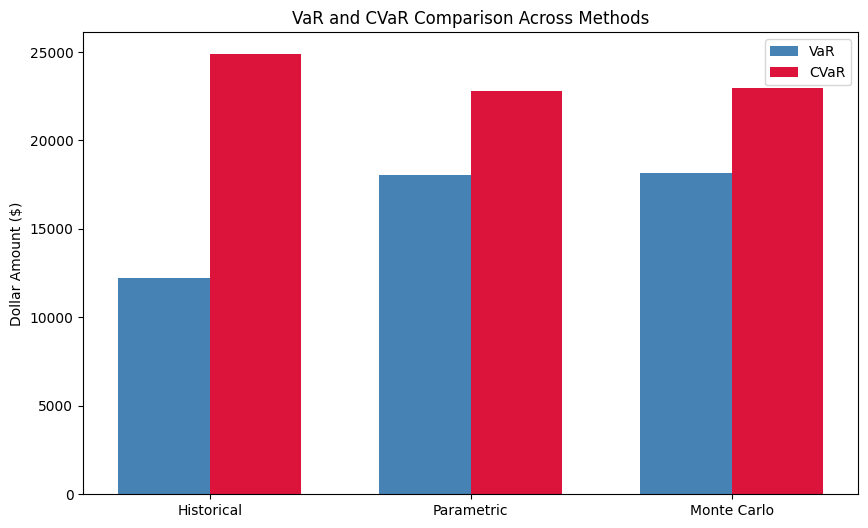

In [49]:
x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, var_values, width, color='steelblue', label='VaR')
plt.bar(x + width/2, cvar_values, width, color='crimson', label='CVaR')
plt.legend()
plt.xticks(x, methods)
plt.ylabel('Dollar Amount ($)')
plt.title('VaR and CVaR Comparison Across Methods')
plt.show()